In [2]:
import pandas as pd
raw_data = pd.read_csv(r"E:\实习\阿里天池项目\UserBehavior.csv",names=['user_id','item_id','catagory_id','behavior_type','datatimes'])
print(raw_data.head(5))

   user_id  item_id  catagory_id behavior_type   datatimes
0        1  2268318      2520377            pv  1511544070
1        1  2333346      2520771            pv  1511561733
2        1  2576651       149192            pv  1511572885
3        1  3830808      4181361            pv  1511593493
4        1  4365585      2520377            pv  1511596146


In [3]:
# 统计基础信息
print(raw_data.info())#检查缺失值和数据类型

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100150807 entries, 0 to 100150806
Data columns (total 5 columns):
 #   Column         Dtype 
---  ------         ----- 
 0   user_id        int64 
 1   item_id        int64 
 2   catagory_id    int64 
 3   behavior_type  object
 4   datatimes      int64 
dtypes: int64(4), object(1)
memory usage: 3.7+ GB
None


In [5]:
print(raw_data.describe())#数值型字段分布
# 数据的时间应该是2017年11月25日至2017年12月3日，部分时间戳显然存在问题

            user_id       item_id   catagory_id     datatimes
count  1.001508e+08  1.001508e+08  1.001508e+08  1.001508e+08
mean   5.069431e+05  2.579775e+06  2.696380e+06  1.511951e+09
std    2.940605e+05  1.488056e+06  1.463155e+06  5.528006e+06
min    1.000000e+00  1.000000e+00  8.000000e+01 -2.134949e+09
25%    2.524290e+05  1.295225e+06  1.320293e+06  1.511762e+09
50%    5.040150e+05  2.580735e+06  2.671397e+06  1.511965e+09
75%    7.609490e+05  3.862042e+06  4.145813e+06  1.512179e+09
max    1.018011e+06  5.163070e+06  5.162429e+06  2.122867e+09


In [8]:
print(raw_data['behavior_type'].value_counts())# 行为类型分布
print(raw_data['behavior_type'].value_counts(normalize=True).mul(100))# 行为类型分布
# 发现行为类型分布严重不平衡，pv占比89%，buy占比仅2%

behavior_type
pv      89716264
cart     5530446
fav      2888258
buy      2015839
Name: count, dtype: int64
behavior_type
pv      89.581169
cart     5.522118
fav      2.883909
buy      2.012804
Name: proportion, dtype: float64


In [11]:
# 接下来针对上面发现的问题进行进一步分数据清洗
# 首先是针对时间戳的清洗
import datetime
raw_data['timestamp']=pd.to_datetime(raw_data['datatimes'],unit='s')

In [12]:
# 提取时间
raw_data['date'] = raw_data['timestamp'].dt.date #提取日期
raw_data['hour'] = raw_data['timestamp'].dt.hour #提取月份
raw_data['weekday'] = raw_data['timestamp'].dt.weekday #提取星期
#检查时间范围（数据集应覆盖2017-11-25至2017-12-03）
print('时间范围：',raw_data['timestamp'].min(),'',raw_data['timestamp'].max())

时间范围： 1902-05-07 22:32:46  2037-04-09 05:22:35


In [13]:
print(raw_data.head())

   user_id  item_id  catagory_id behavior_type   datatimes  \
0        1  2268318      2520377            pv  1511544070   
1        1  2333346      2520771            pv  1511561733   
2        1  2576651       149192            pv  1511572885   
3        1  3830808      4181361            pv  1511593493   
4        1  4365585      2520377            pv  1511596146   

            timestamp        date  hour  weekday  
0 2017-11-24 17:21:10  2017-11-24    17        4  
1 2017-11-24 22:15:33  2017-11-24    22        4  
2 2017-11-25 01:21:25  2017-11-25     1        5  
3 2017-11-25 07:04:53  2017-11-25     7        5  
4 2017-11-25 07:49:06  2017-11-25     7        5  


In [15]:
# 正式进入数据清洗
# 查看数据集的行数和列数
rows,columns= raw_data.shape
if rows>0:
    # 查看各个列缺失值的情况，
    missing_values=raw_data.isnull().sum()
    print('\n查看各列缺失值的情况：')
    print(missing_values)

    # 处理缺失值，这里简单的删除缺失值的行
    if missing_values.sum()>0:
        raw_data = raw_data.dropna()
        print('\n已删除存在缺失值的行')

    #查看重复值的数量
    duplicate_count = raw_data.duplicated().sum()
    print(f'重复值的数量是：{duplicate_count}')

    # 删除重复值
    if duplicate_count>0:
        raw_data = raw_data.drop_duplicates()
        print('重复值已删除')

    # 处理异常值，包括时间异常数据
    start_date = pd.Timestamp('2017-11-25')
    end_date = pd.Timestamp('2017-12-03')
    outlies_mask = (raw_data['timestamp']<start_date)|(raw_data['timestamp']>end_date)
    outlies_count = outlies_mask.sum()

    if outlies_count > 0:
        clean_data = raw_data[~outlies_mask]
        print('已删除时间异常值')


查看各列缺失值的情况：
user_id          0
item_id          0
catagory_id      0
behavior_type    0
datatimes        0
timestamp        0
date             0
hour             0
weekday          0
dtype: int64
重复值的数量是：0
已删除时间异常值


In [17]:
# 查看清洗之后的数据是什么情况
print('清洗后数据的基本情况：',clean_data.info)

清洗后数据的基本情况： <bound method DataFrame.info of            user_id  item_id  catagory_id behavior_type   datatimes  \
2                1  2576651       149192            pv  1511572885   
3                1  3830808      4181361            pv  1511593493   
4                1  4365585      2520377            pv  1511596146   
5                1  4606018      2735466            pv  1511616481   
6                1   230380       411153            pv  1511644942   
...            ...      ...          ...           ...         ...   
100150790   999999  4929832      4602841            pv  1512218394   
100150791   999999  1492928      4794845            pv  1512218443   
100150792   999999  2879219      4794845            pv  1512218469   
100150793   999999  1497516      1817077            pv  1512218581   
100150794   999999  4466226      1817077            pv  1512218599   

                    timestamp        date  hour  weekday  
2         2017-11-25 01:21:25  2017-11-25     1        5

In [20]:
# 将清洗后的数据保存起来
clean_data_path = r'E:\实习\阿里天池项目\清洗后的数据\clean_data.csv'
clean_data.to_csv(clean_data_path,index=False)

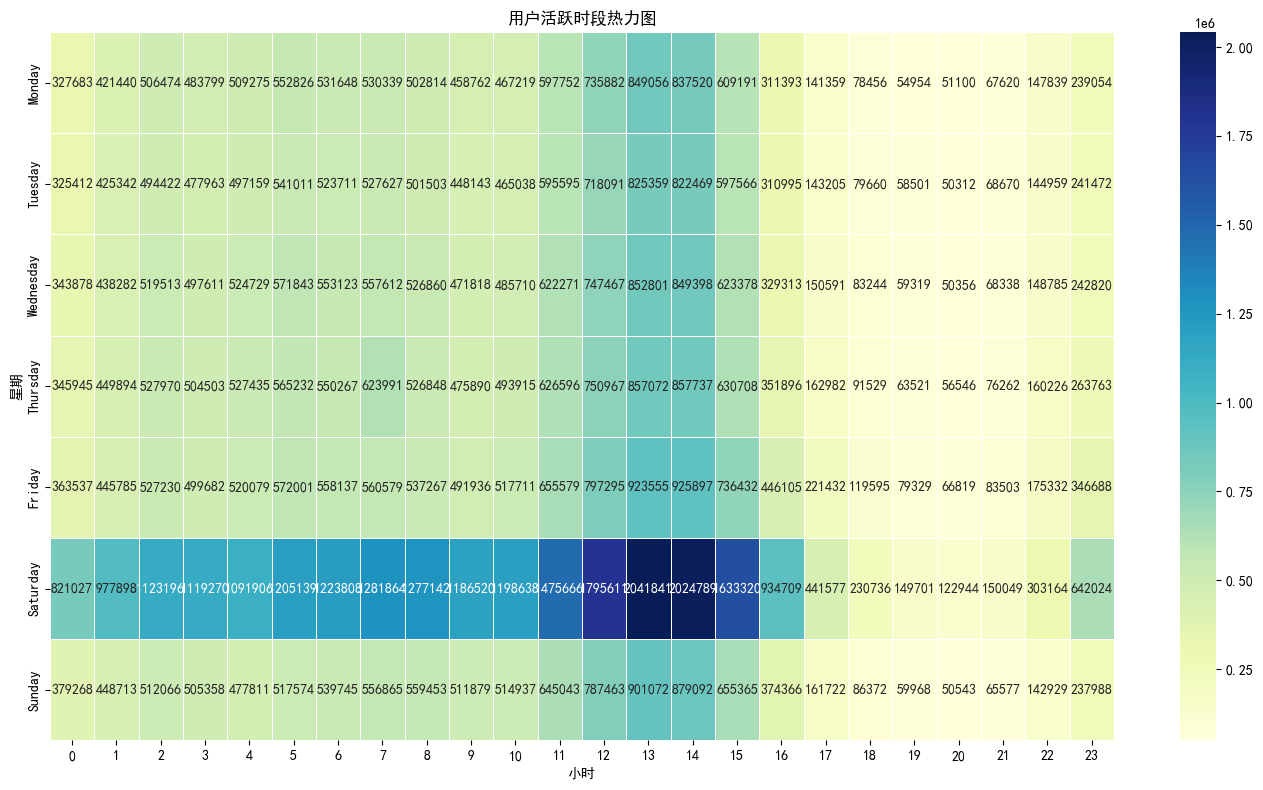

In [22]:
# 部分数据可视化
# 查看每周各个时间段的用户活跃情况
import matplotlib.pyplot as plt
import seaborn as sns

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 创建热力图数据
hourly_activity = clean_data.groupby(['weekday','hour']).size().unstack(fill_value = 0)

# 重命名索引
weekday_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
hourly_activity.index = weekday_names

# 绘制热力图
plt.figure(figsize=(14,8))
sns.heatmap(hourly_activity, cmap="YlGnBu", annot=True, fmt="d", linewidths=.5)
plt.title('用户活跃时段热力图')
plt.xlabel('小时')
plt.ylabel('星期')
plt.tight_layout()
plt.show()